## Hands on Lab Day 4

### Re-implement the Day 2 star-schema transformation logic twice — once in PySpark, once in Spark SQL — confirm identical output, and note where each API felt more natural.

### Flow to access JSON data

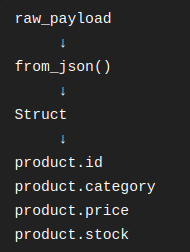

### Hands on Lab Approach

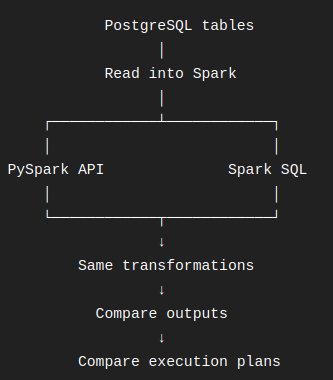

#### Step 1: Create Spark Session

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Hands-on-Lab-4") \
    .config("spark.jars", "/home/leapfrog/postgresql-42.7.4.jar") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/20 09:59:56 WARN Utils: Your hostname, LF-00002297, resolves to a loopback address: 127.0.1.1; using 192.168.1.85 instead (on interface wlp0s20f3)
26/09/20 09:59:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/09/20 09:59:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/leapfrog/LakeHouse-Fifteen---Data-Engineering-Course/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


#### Step 1: Connect Spark to PostGreSQL to load the tables

In [2]:
jdbc_url = "jdbc:postgresql://localhost:5433/data-pipeline"

properties = {
    "user": "postgres",
    "password": "postgres",
    "driver": "org.postgresql.Driver"
}

#### Step 2: Read Staging Data

In [7]:
# Reading Staging data

stg_products = spark.read.jdbc(
    jdbc_url,
    "staging.stg_products",
    properties=properties
)


In [16]:
stg_products.show()

raw_payload = stg_products.first()['raw_payload']

raw_payload

+---+--------------------+--------------------+
| id|         raw_payload|        extracted_at|
+---+--------------------+--------------------+
|  1|{"id": 1, "sku": ...|2026-09-09 14:59:...|
|  2|{"id": 2, "sku": ...|2026-09-09 14:59:...|
|  3|{"id": 3, "sku": ...|2026-09-09 14:59:...|
|  4|{"id": 4, "sku": ...|2026-09-09 14:59:...|
|  5|{"id": 5, "sku": ...|2026-09-09 14:59:...|
|  6|{"id": 6, "sku": ...|2026-09-09 14:59:...|
|  7|{"id": 7, "sku": ...|2026-09-09 14:59:...|
|  8|{"id": 8, "sku": ...|2026-09-09 14:59:...|
|  9|{"id": 9, "sku": ...|2026-09-09 14:59:...|
| 10|{"id": 10, "sku":...|2026-09-09 14:59:...|
| 11|{"id": 11, "sku":...|2026-09-09 14:59:...|
| 12|{"id": 12, "sku":...|2026-09-09 14:59:...|
| 13|{"id": 13, "sku":...|2026-09-09 14:59:...|
| 14|{"id": 14, "sku":...|2026-09-09 14:59:...|
| 15|{"id": 15, "sku":...|2026-09-09 14:59:...|
| 16|{"id": 16, "sku":...|2026-09-09 14:59:...|
| 17|{"id": 17, "sku":...|2026-09-09 14:59:...|
| 18|{"id": 18, "sku":...|2026-09-09 14:

'{"id": 1, "sku": "BEA-ESS-ESS-001", "meta": {"qrCode": "https://cdn.dummyjson.com/public/qr-code.png", "barcode": "5784719087687", "createdAt": "2025-04-30T09:41:02.053Z", "updatedAt": "2025-04-30T09:41:02.053Z"}, "tags": ["beauty", "mascara"], "brand": "Essence", "price": 9.99, "stock": 99, "title": "Essence Mascara Lash Princess", "images": ["https://cdn.dummyjson.com/product-images/beauty/essence-mascara-lash-princess/1.webp"], "rating": 2.56, "weight": 4, "reviews": [{"date": "2025-04-30T09:41:02.053Z", "rating": 3, "comment": "Would not recommend!", "reviewerName": "Eleanor Collins", "reviewerEmail": "eleanor.collins@x.dummyjson.com"}, {"date": "2025-04-30T09:41:02.053Z", "rating": 4, "comment": "Very satisfied!", "reviewerName": "Lucas Gordon", "reviewerEmail": "lucas.gordon@x.dummyjson.com"}, {"date": "2025-04-30T09:41:02.053Z", "rating": 5, "comment": "Highly impressed!", "reviewerName": "Eleanor Collins", "reviewerEmail": "eleanor.collins@x.dummyjson.com"}], "category": "beau

#### Step 3: Convet Raw JSON Data onto structured form

In [28]:
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType,
    ArrayType
)

from pyspark.sql.functions import col , from_json 

# Define the schema that matches the json data

product_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("sku", StringType(), True),

    StructField("meta", StructType([
        StructField("qrCode", StringType(), True),
        StructField("barcode", StringType(), True),
        StructField("createdAt", StringType(), True),
        StructField("updatedAt", StringType(), True)
    ]), True),

    StructField("tags", ArrayType(StringType()), True),

    StructField("brand", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("stock", IntegerType(), True),
    StructField("title", StringType(), True),

    StructField("images", ArrayType(StringType()), True),

    StructField("rating", DoubleType(), True),
    StructField("weight", IntegerType(), True),

    StructField("reviews", ArrayType(
        StructType([
            StructField("date", StringType(), True),
            StructField("rating", IntegerType(), True),
            StructField("comment", StringType(), True),
            StructField("reviewerName", StringType(), True),
            StructField("reviewerEmail", StringType(), True)
        ])
    ), True),

    StructField("category", StringType(), True),
    StructField("thumbnail", StringType(), True),

    StructField("dimensions", StructType([
        StructField("depth", DoubleType(), True),
        StructField("width", DoubleType(), True),
        StructField("height", DoubleType(), True)
    ]), True),

    StructField("description", StringType(), True),
    StructField("returnPolicy", StringType(), True),
    StructField("availabilityStatus", StringType(), True),
    StructField("discountPercentage", DoubleType(), True),
    StructField("shippingInformation", StringType(), True),
    StructField("warrantyInformation", StringType(), True),
    StructField("minimumOrderQuantity", IntegerType(), True)
])

# convert raw_json to a single column data that stores struct data
stg= stg_products.withColumn(
    'product',
    from_json("raw_payload",product_schema)
).drop("raw_payload")

stg.schema["product"].dataType # We can see that this is a Struct

stg.show()


+---+--------------------+--------------------+
| id|        extracted_at|             product|
+---+--------------------+--------------------+
|  1|2026-09-09 14:59:...|{1, BEA-ESS-ESS-0...|
|  2|2026-09-09 14:59:...|{2, BEA-GLA-EYE-0...|
|  3|2026-09-09 14:59:...|{3, BEA-VEL-POW-0...|
|  4|2026-09-09 14:59:...|{4, BEA-CHI-LIP-0...|
|  5|2026-09-09 14:59:...|{5, BEA-NAI-NAI-0...|
|  6|2026-09-09 14:59:...|{6, FRA-CAL-CAL-0...|
|  7|2026-09-09 14:59:...|{7, FRA-CHA-CHA-0...|
|  8|2026-09-09 14:59:...|{8, FRA-DIO-DIO-0...|
|  9|2026-09-09 14:59:...|{9, FRA-DOL-DOL-0...|
| 10|2026-09-09 14:59:...|{10, FRA-GUC-GUC-...|
| 11|2026-09-09 14:59:...|{11, FUR-ANN-ANN-...|
| 12|2026-09-09 14:59:...|{12, FUR-ANN-ANN-...|
| 13|2026-09-09 14:59:...|{13, FUR-FUR-BED-...|
| 14|2026-09-09 14:59:...|{14, FUR-KNO-KNO-...|
| 15|2026-09-09 14:59:...|{15, FUR-BAT-WOO-...|
| 16|2026-09-09 14:59:...|{16, GRO-BRD-APP-...|
| 17|2026-09-09 14:59:...|{17, GRO-BRD-BEE-...|
| 18|2026-09-09 14:59:...|{18, GRO-BRD-F

In [40]:
stg_products_pyspark = stg.select(
    "product.id",
    "product.sku",
    "product.brand",
    "product.price",
    "product.stock",
    "product.title",
    "product.rating",
    "product.category",
    "product.description",
    "product.discountPercentage",
    "product.minimumOrderQuantity"
)

stg_products_pyspark.show()

+---+---------------+----------------+-------+-----+--------------------+------+----------+--------------------+------------------+--------------------+
| id|            sku|           brand|  price|stock|               title|rating|  category|         description|discountPercentage|minimumOrderQuantity|
+---+---------------+----------------+-------+-----+--------------------+------+----------+--------------------+------------------+--------------------+
|  1|BEA-ESS-ESS-001|         Essence|   9.99|   99|Essence Mascara L...|  2.56|    beauty|The Essence Masca...|             10.48|                  48|
|  2|BEA-GLA-EYE-002|  Glamour Beauty|  19.99|   34|Eyeshadow Palette...|  2.86|    beauty|The Eyeshadow Pal...|             18.19|                  20|
|  3|BEA-VEL-POW-003|    Velvet Touch|  14.99|   89|     Powder Canister|  4.64|    beauty|The Powder Canist...|              9.84|                  22|
|  4|BEA-CHI-LIP-004|  Chic Cosmetics|  12.99|   91|        Red Lipstick|  4.36|  

#### Step 4: Create Temp View for Spark SQL

In [41]:
stg.createOrReplaceTempView("stg_products_sql")



In [42]:
spark.sql("""
SELECT * FROM 
stg_products_sql
 """).show()

+---+--------------------+--------------------+
| id|        extracted_at|             product|
+---+--------------------+--------------------+
|  1|2026-09-09 14:59:...|{1, BEA-ESS-ESS-0...|
|  2|2026-09-09 14:59:...|{2, BEA-GLA-EYE-0...|
|  3|2026-09-09 14:59:...|{3, BEA-VEL-POW-0...|
|  4|2026-09-09 14:59:...|{4, BEA-CHI-LIP-0...|
|  5|2026-09-09 14:59:...|{5, BEA-NAI-NAI-0...|
|  6|2026-09-09 14:59:...|{6, FRA-CAL-CAL-0...|
|  7|2026-09-09 14:59:...|{7, FRA-CHA-CHA-0...|
|  8|2026-09-09 14:59:...|{8, FRA-DIO-DIO-0...|
|  9|2026-09-09 14:59:...|{9, FRA-DOL-DOL-0...|
| 10|2026-09-09 14:59:...|{10, FRA-GUC-GUC-...|
| 11|2026-09-09 14:59:...|{11, FUR-ANN-ANN-...|
| 12|2026-09-09 14:59:...|{12, FUR-ANN-ANN-...|
| 13|2026-09-09 14:59:...|{13, FUR-FUR-BED-...|
| 14|2026-09-09 14:59:...|{14, FUR-KNO-KNO-...|
| 15|2026-09-09 14:59:...|{15, FUR-BAT-WOO-...|
| 16|2026-09-09 14:59:...|{16, GRO-BRD-APP-...|
| 17|2026-09-09 14:59:...|{17, GRO-BRD-BEE-...|
| 18|2026-09-09 14:59:...|{18, GRO-BRD-F


#### Step 5: Transformation 1: *dim_category*


Original transformation:

```
INSERT INTO warehouse.dim_category (category_name)

SELECT DISTINCT
    raw_payload->>'category'
FROM staging.stg_products
WHERE raw_payload->>'category' IS NOT NULL
ON CONFLICT (category_name) DO NOTHING;

```

Transformation we need to follow:

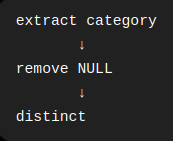

##### PySpark Implementation

In [44]:
from pyspark.sql.functions import col

dim_category_pyspark = stg_products_pyspark.select(
    "category"
).filter(col("category").isNotNull()).distinct()

dim_category_pyspark.show()

+-------------------+
|           category|
+-------------------+
|         motorcycle|
|   womens-jewellery|
|     womens-watches|
|         mens-shoes|
|         fragrances|
|             beauty|
|          groceries|
|         sunglasses|
|        womens-bags|
|kitchen-accessories|
|            tablets|
| mobile-accessories|
|       womens-shoes|
|        mens-shirts|
|          skin-care|
|          furniture|
|    home-decoration|
|            laptops|
| sports-accessories|
|        smartphones|
+-------------------+
only showing top 20 rows


##### SparlSQL Implementation

In [47]:
spark.sql("""
SELECT DISTINCT
    product.category as category_name
FROM stg_products_sql
WHERE product.category IS NOT NULL
""").show()

+-------------------+
|      category_name|
+-------------------+
|         motorcycle|
|   womens-jewellery|
|     womens-watches|
|         mens-shoes|
|         fragrances|
|             beauty|
|          groceries|
|         sunglasses|
|        womens-bags|
|kitchen-accessories|
|            tablets|
| mobile-accessories|
|       womens-shoes|
|        mens-shirts|
|          skin-care|
|          furniture|
|    home-decoration|
|            laptops|
| sports-accessories|
|        smartphones|
+-------------------+
only showing top 20 rows


#### Step 6: Transformation 2: *dim_date*

Original SQL file code:

``` 
INSERT INTO warehouse.dim_date (date_key, full_date, year, month, day, quarter)
SELECT
    -- date_key as YYYYMMDD integer — efficient for joins in the fact table
    CAST(TO_CHAR(d, 'YYYYMMDD') AS INT)   AS date_key,
    d::DATE                                AS full_date,
    EXTRACT(YEAR    FROM d)::INT           AS year,
    EXTRACT(MONTH   FROM d)::INT           AS month,
    EXTRACT(DAY     FROM d)::INT           AS day,
    EXTRACT(QUARTER FROM d)::INT           AS quarter
FROM generate_series(
    '2024-01-01'::DATE,
    '2030-12-31'::DATE,
    '1 day'::INTERVAL
) AS d
ON CONFLICT (date_key) DO NOTHING;

```



#### PySpark Implementation 

In [57]:
# Creating a DF for the dates

dates_df = spark.sql(
"""
    SELECT 
        explode(
            sequence(
                to_date('2024-01-01'),
                to_date('2030-12-01'),
                interval 1 day
            )
        ) as date
"""
)

In [58]:
dates_df.show()

+----------+
|      date|
+----------+
|2024-01-01|
|2024-01-02|
|2024-01-03|
|2024-01-04|
|2024-01-05|
|2024-01-06|
|2024-01-07|
|2024-01-08|
|2024-01-09|
|2024-01-10|
|2024-01-11|
|2024-01-12|
|2024-01-13|
|2024-01-14|
|2024-01-15|
|2024-01-16|
|2024-01-17|
|2024-01-18|
|2024-01-19|
|2024-01-20|
+----------+
only showing top 20 rows


In [74]:
from pyspark.sql.functions import date_format,year,month,dayofmonth,quarter

date_dim_pyspark = dates_df.withColumn(
    "date_key",
    date_format("date" , 'yyyyMMdd')
).withColumn("year" , year("date")).withColumn("month", month("date")).withColumn("day" , dayofmonth('date')).withColumn("quarter" , quarter('date'))

In [75]:
date_dim_pyspark.show()

+----------+--------+----+-----+---+-------+
|      date|date_key|year|month|day|quarter|
+----------+--------+----+-----+---+-------+
|2024-01-01|20240101|2024|    1|  1|      1|
|2024-01-02|20240102|2024|    1|  2|      1|
|2024-01-03|20240103|2024|    1|  3|      1|
|2024-01-04|20240104|2024|    1|  4|      1|
|2024-01-05|20240105|2024|    1|  5|      1|
|2024-01-06|20240106|2024|    1|  6|      1|
|2024-01-07|20240107|2024|    1|  7|      1|
|2024-01-08|20240108|2024|    1|  8|      1|
|2024-01-09|20240109|2024|    1|  9|      1|
|2024-01-10|20240110|2024|    1| 10|      1|
|2024-01-11|20240111|2024|    1| 11|      1|
|2024-01-12|20240112|2024|    1| 12|      1|
|2024-01-13|20240113|2024|    1| 13|      1|
|2024-01-14|20240114|2024|    1| 14|      1|
|2024-01-15|20240115|2024|    1| 15|      1|
|2024-01-16|20240116|2024|    1| 16|      1|
|2024-01-17|20240117|2024|    1| 17|      1|
|2024-01-18|20240118|2024|    1| 18|      1|
|2024-01-19|20240119|2024|    1| 19|      1|
|2024-01-2

#### Spark SQL implementation 

In [76]:
# Convert the date_df into view first

dates_df.createOrReplaceTempView("date_view")

# Access the date view and create the required Structure

spark.sql(
'''
    SELECT 
        CAST(date_format(date, 'yyyyMMdd') AS INT ) AS date_key,
        date  AS full_date,
        year(date) AS year,
        month(date) AS month,
        dayofmonth(date) AS day,
        quarter(date) AS quarter
    FROM date_view
''').show()

+--------+----------+----+-----+---+-------+
|date_key| full_date|year|month|day|quarter|
+--------+----------+----+-----+---+-------+
|20240101|2024-01-01|2024|    1|  1|      1|
|20240102|2024-01-02|2024|    1|  2|      1|
|20240103|2024-01-03|2024|    1|  3|      1|
|20240104|2024-01-04|2024|    1|  4|      1|
|20240105|2024-01-05|2024|    1|  5|      1|
|20240106|2024-01-06|2024|    1|  6|      1|
|20240107|2024-01-07|2024|    1|  7|      1|
|20240108|2024-01-08|2024|    1|  8|      1|
|20240109|2024-01-09|2024|    1|  9|      1|
|20240110|2024-01-10|2024|    1| 10|      1|
|20240111|2024-01-11|2024|    1| 11|      1|
|20240112|2024-01-12|2024|    1| 12|      1|
|20240113|2024-01-13|2024|    1| 13|      1|
|20240114|2024-01-14|2024|    1| 14|      1|
|20240115|2024-01-15|2024|    1| 15|      1|
|20240116|2024-01-16|2024|    1| 16|      1|
|20240117|2024-01-17|2024|    1| 17|      1|
|20240118|2024-01-18|2024|    1| 18|      1|
|20240119|2024-01-19|2024|    1| 19|      1|
|20240120|


#### Step 7: Transformation 3: *dim_products*


Original transformation:

```
UPDATE warehouse.dim_product AS dp
SET    is_current = FALSE,
       valid_to   = CURRENT_DATE
FROM   staging.stg_products AS s
WHERE  dp.product_id  = (s.raw_payload->>'id')::INT
  AND  dp.is_current  = TRUE
  AND  (
           -- price changed
           (s.raw_payload->>'price')::NUMERIC(10,2)  IS DISTINCT FROM dp.price
           OR
           -- rating changed
           (s.raw_payload->>'rating')::NUMERIC(3,2)  IS DISTINCT FROM dp.rating
       );

-- ── B: Insert new version for every product that was just expired ───────────
INSERT INTO warehouse.dim_product
    (product_id, title, brand, description, price, rating, is_current, valid_from, valid_to)
SELECT
    (s.raw_payload->>'id')::INT,
    s.raw_payload->>'title',
    s.raw_payload->>'brand',
    s.raw_payload->>'description',
    (s.raw_payload->>'price')::NUMERIC(10,2),
    (s.raw_payload->>'rating')::NUMERIC(3,2),
    TRUE,
    CURRENT_DATE,
    NULL          -- NULL valid_to = still the active record
FROM staging.stg_products AS s
WHERE EXISTS (
    -- only for products we just expired (valid_to = today, no longer current)
    SELECT 1
    FROM   warehouse.dim_product AS dp
    WHERE  dp.product_id = (s.raw_payload->>'id')::INT
      AND  dp.is_current = FALSE
      AND  dp.valid_to   = CURRENT_DATE
)
AND NOT EXISTS (
    -- guard: skip if a current row already exists (re-run safety)
    SELECT 1
    FROM   warehouse.dim_product AS dp
    WHERE  dp.product_id = (s.raw_payload->>'id')::INT
      AND  dp.is_current = TRUE
);

-- ── C: Insert brand-new products (no prior dim_product row at all) ──────────
INSERT INTO warehouse.dim_product
    (product_id, title, brand, description, price, rating, is_current, valid_from, valid_to)
SELECT
    (s.raw_payload->>'id')::INT,
    s.raw_payload->>'title',
    s.raw_payload->>'brand',
    s.raw_payload->>'description',
    (s.raw_payload->>'price')::NUMERIC(10,2),
    (s.raw_payload->>'rating')::NUMERIC(3,2),
    TRUE,
    CURRENT_DATE,
    NULL
FROM staging.stg_products AS s
WHERE NOT EXISTS (
    SELECT 1
    FROM   warehouse.dim_product AS dp
    WHERE  dp.product_id = (s.raw_payload->>'id')::INT
);

```

In [80]:
# Creating a Dataframe to represent the dim_products table


from pyspark.sql.functions import (
    col, lit, current_date,monotonically_increasing_id
)

existing_dim_products = (
    stg_products_pyspark
    .select(
        col("id").alias("product_id"),
        "title",
        "price",
        "rating"
    )
    .withColumn("product_sk", monotonically_increasing_id())
    .withColumn("valid_from", current_date())
    .withColumn("valid_to", lit(None).cast("date"))
    .withColumn("is_current", lit(True))
)

In [ ]:
existing_dim_products.show()

+----------+--------------------+-------+------+----------+----------+--------+----------+
|product_id|               title|  price|rating|product_sk|valid_from|valid_to|is_current|
+----------+--------------------+-------+------+----------+----------+--------+----------+
|         1|Essence Mascara L...|   9.99|  2.56|         0|2026-09-20|    NULL|      true|
|         2|Eyeshadow Palette...|  19.99|  2.86|         1|2026-09-20|    NULL|      true|
|         3|     Powder Canister|  14.99|  4.64|         2|2026-09-20|    NULL|      true|
|         4|        Red Lipstick|  12.99|  4.36|         3|2026-09-20|    NULL|      true|
|         5|     Red Nail Polish|   8.99|  4.32|         4|2026-09-20|    NULL|      true|
|         6| Calvin Klein CK One|  49.99|  4.37|         5|2026-09-20|    NULL|      true|
|         7|Chanel Coco Noir ...| 129.99|  4.26|         6|2026-09-20|    NULL|      true|
|         8|        Dior J'adore|  89.99|   3.8|         7|2026-09-20|    NULL|      true|

In [87]:
existing_dim_products.filter(existing_dim_products.title == 'Apple').show()

+----------+-----+-----+------+----------+----------+--------+----------+
|product_id|title|price|rating|product_sk|valid_from|valid_to|is_current|
+----------+-----+-----+------+----------+----------+--------+----------+
|        16|Apple| 1.99|  4.19|        15|2026-09-20|    NULL|      true|
+----------+-----+-----+------+----------+----------+--------+----------+



In [88]:
existing_dim_products.count()

194

In [91]:
dummmy_staging_data = [
    (16, "Apple",      2.00, 4.19),   # changed price
    (17, "Beef Steak",    12.99, 4.47),   # unchanged
    (18, "Cat Food",   8.99 , 4.0),    # changed rating
    (195, "Phone" , 150.00 , 5.0) # New product
]

dummy_staging_df = spark.createDataFrame(
    dummmy_staging_data,
    ["product_id", "title", "price", "rating"]
)

dummy_staging_df.show()


+----------+----------+-----+------+
|product_id|     title|price|rating|
+----------+----------+-----+------+
|        16|     Apple|  2.0|  4.19|
|        17|Beef Steak|12.99|  4.47|
|        18|  Cat Food| 8.99|   4.0|
|       195|     Phone|150.0|   5.0|
+----------+----------+-----+------+



#### Changed Products Transformation Logic


##### PySpark

- identify the changed products
- expire the old version
- insert the new version

In [92]:
from pyspark.sql.functions import (
    col, lit, current_date,
    max as spark_max,
    row_number
)
from pyspark.sql.window import Window

In [94]:
dim_stg = (
    existing_dim_products.alias("dim")
    .join(
        dummy_staging_df.alias("stg"),
        col("dim.product_id") == col("stg.product_id"),
        "inner"
    )
)


In [95]:
dim_stg.show()

+----------+----------+-----+------+----------+----------+--------+----------+----------+----------+-----+------+
|product_id|     title|price|rating|product_sk|valid_from|valid_to|is_current|product_id|     title|price|rating|
+----------+----------+-----+------+----------+----------+--------+----------+----------+----------+-----+------+
|        16|     Apple| 1.99|  4.19|        15|2026-09-20|    NULL|      true|        16|     Apple|  2.0|  4.19|
|        17|Beef Steak|12.99|  4.47|        16|2026-09-20|    NULL|      true|        17|Beef Steak|12.99|  4.47|
|        18|  Cat Food| 8.99|  3.13|        17|2026-09-20|    NULL|      true|        18|  Cat Food| 8.99|   4.0|
+----------+----------+-----+------+----------+----------+--------+----------+----------+----------+-----+------+



In [96]:
expired_products = (
    dim_stg
    .filter(
        col("dim.is_current") &
        (
            (col("dim.price") != col("stg.price")) |
            (col("dim.rating") != col("stg.rating"))
        )
    )
    .select("dim.*")
    .withColumn("is_current", lit(False))
    .withColumn("valid_to", current_date())
)

In [97]:
expired_products.show()

+----------+--------+-----+------+----------+----------+----------+----------+
|product_id|   title|price|rating|product_sk|valid_from|  valid_to|is_current|
+----------+--------+-----+------+----------+----------+----------+----------+
|        16|   Apple| 1.99|  4.19|        15|2026-09-20|2026-09-20|     false|
|        18|Cat Food| 8.99|  3.13|        17|2026-09-20|2026-09-20|     false|
+----------+--------+-----+------+----------+----------+----------+----------+



In [98]:
# Creating new_changed_products

new_changed_products = (
    dim_stg
    .filter(
        col("dim.is_current") &
        (
            (col("dim.price") != col("stg.price")) |
            (col("dim.rating") != col("stg.rating"))
        )
    )
    .select(
        col("stg.product_id").alias("product_id"),
        col("stg.title").alias("title"),
        col("stg.price").alias("price"),
        col("stg.rating").alias("rating")
    )
    .withColumn("valid_from", current_date())
    .withColumn("valid_to", lit(None).cast("date"))
    .withColumn("is_current", lit(True))
)

In [101]:
# Adding a new unique surrogate key for the new_changed_products
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window = Window.orderBy('product_id')

new_changed_products = new_changed_products.withColumn("product_sk" , row_number().over(window) + existing_dim_products.agg({"product_sk": "max"}).first()[0])



In [102]:
new_changed_products.show()

26/09/20 12:46:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:46:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:46:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:46:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:46:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:46:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 1

+----------+--------+-----+------+----------+--------+----------+----------+
|product_id|   title|price|rating|valid_from|valid_to|is_current|product_sk|
+----------+--------+-----+------+----------+--------+----------+----------+
|        16|   Apple|  2.0|  4.19|2026-09-20|    NULL|      true|       194|
|        18|Cat Food| 8.99|   4.0|2026-09-20|    NULL|      true|       195|
+----------+--------+-----+------+----------+--------+----------+----------+



In [111]:
from pyspark.sql.functions import (
    col,
    lit,
    current_date,
    max as spark_max,
    row_number
)
from pyspark.sql.window import Window


def apply_scd2(existing_dim_df, staging_df):

    # --------------------------------------------------
    # 1. Join existing dimension with incoming staging
    # --------------------------------------------------

    dim_stg = (
        existing_dim_df.alias("dim")
        .join(
            staging_df.alias("stg"),
            col("dim.product_id") == col("stg.product_id"),
            "full_outer"
        )
    )



    # --------------------------------------------------
    # 2. Identify CHANGED products
    # --------------------------------------------------

    changed = (
        dim_stg
        .filter(
            col("dim.product_id").isNotNull() &
            col("stg.product_id").isNotNull() &
            col("dim.is_current") &
            (
                (col("dim.price") != col("stg.price")) |
                (col("dim.rating") != col("stg.rating")) |
                (col("dim.title") != col("stg.title"))
            )
        )
    )


    # --------------------------------------------------
    # 3. Expire old versions of CHANGED products
    # --------------------------------------------------

    expired_products = (
        changed
        .select("dim.*")
        .withColumn("is_current", lit(False))
        .withColumn("valid_to", current_date())
    )


    # --------------------------------------------------
    # 4. Create NEW versions of changed products
    # --------------------------------------------------

    new_changed_products = (
        changed
        .select(
            col("stg.product_id").alias("product_id"),
            col("stg.title").alias("title"),
            col("stg.price").alias("price"),
            col("stg.rating").alias("rating")
        )
        .withColumn("valid_from", current_date())
        .withColumn(
            "valid_to",
            lit(None).cast("date")
        )
        .withColumn(
            "is_current",
            lit(True)
        )
    )


    # --------------------------------------------------
    # 5. Identify UNCHANGED products
    # --------------------------------------------------

    unchanged_products = (
        dim_stg
        .filter(
            col("dim.product_id").isNotNull() &
            col("stg.product_id").isNotNull() &
            col("dim.is_current") &
            (col("dim.price") == col("stg.price")) &
            (col("dim.rating") == col("stg.rating")) &
            (col("dim.title") == col("stg.title"))
        )
        .select("dim.*")
    )



    # --------------------------------------------------
    # 6. Identify completely NEW products
    # --------------------------------------------------

    new_products = (
        dim_stg
        .filter(
            col("dim.product_id").isNull() &
            col("stg.product_id").isNotNull()
        )
        .select(
            col("stg.product_id").alias("product_id"),
            col("stg.title").alias("title"),
            col("stg.price").alias("price"),
            col("stg.rating").alias("rating")
        )
        .withColumn(
            "valid_from",
            current_date()
        )
        .withColumn(
            "valid_to",
            lit(None).cast("date")
        )
        .withColumn(
            "is_current",
            lit(True)
        )
    )


    # --------------------------------------------------
    # 7. Generate surrogate keys
    # --------------------------------------------------

    max_sk = (
        existing_dim_df
        .agg(spark_max("product_sk"))
        .first()[0]
    )

    # Number all newly-created rows
    new_rows = (
        new_changed_products
        .unionByName(new_products)
    )

    window = Window.orderBy("product_id")

    new_rows = (
        new_rows
        .withColumn(
            "product_sk",
            row_number().over(window) + max_sk
        )
    )


    # --------------------------------------------------
    # 8. Construct the final dimension
    # --------------------------------------------------

    updated_dim_df = (
        unchanged_products
        .unionByName(expired_products)
        .unionByName(new_rows)
    )

    return updated_dim_df

In [112]:
updated_dim_products = apply_scd2(
    existing_dim_products,
    dummy_staging_df
)

In [105]:
updated_dim_products.show()

26/09/20 12:51:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:51:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:51:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:51:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:51:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 12:51:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/20 1

+----------+----------+-----+------+----------+----------+----------+----------+
|product_id|     title|price|rating|product_sk|valid_from|  valid_to|is_current|
+----------+----------+-----+------+----------+----------+----------+----------+
|        17|Beef Steak|12.99|  4.47|        16|2026-09-20|      NULL|      true|
|        16|     Apple| 1.99|  4.19|        15|2026-09-20|2026-09-20|     false|
|        18|  Cat Food| 8.99|  3.13|        17|2026-09-20|2026-09-20|     false|
|        16|     Apple|  2.0|  4.19|       194|2026-09-20|      NULL|      true|
|        18|  Cat Food| 8.99|   4.0|       195|2026-09-20|      NULL|      true|
|       195|     Phone|150.0|   5.0|       196|2026-09-20|      NULL|      true|
+----------+----------+-----+------+----------+----------+----------+----------+

